<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Playground to Test: Do Signals have Predictive Power?
___

</div>

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

from modules.signals.fetch import get_sp500_universe, fetch_price_data, START_DATE, END_DATE
from modules.signals.momentum import compute_momentum
from modules.signals.mean_reversion import compute_mean_reversion
from modules.signals.testing import evaluate_signal

import pandas as pd

In [ ]:
from modules.signals.fetch import save_price_data

universe = get_sp500_universe()
print(f"{len(universe)} tickers across {universe['Sector'].nunique()} sectors")
close, volume = fetch_price_data(universe["Symbol"].tolist(), start=START_DATE, end=END_DATE)

failed_tickers = close.columns[close.isna().all()].tolist()
if failed_tickers:
    close = close.drop(columns=failed_tickers)
    volume = volume.drop(columns=failed_tickers)

save_price_data(universe, close, volume)
print(f"Close shape: {close.shape}")

# once the data's been saved...

# from modules.signals.fetch import load_price_data

# universe, close, volume = load_price_data()
# print(f"Close shape: {close.shape}")
# close.tail()

Fetching batch 1 / 13 (40 tickers)...


[*********************100%***********************]  40 of 40 completed


Fetching batch 2 / 13 (40 tickers)...


[*********************100%***********************]  40 of 40 completed


Fetching batch 3 / 13 (40 tickers)...


...

Fetching batch 12 / 13 (40 tickers)...


[*********************100%***********************]  40 of 40 completed


Fetching batch 13 / 13 (23 tickers)...


[*********************100%***********************]  23 of 23 completed


Saved universe, close, and volume to /Users/paulgrajzl/Documents/Quant-Projects/systematic-portfolio-engine-equities-1/data/
Close shape: (1907, 503)


In [5]:
momentum_signal = compute_momentum(close)
mean_reversion_signal = compute_mean_reversion(close)

print(f"Momentum shape: {momentum_signal.shape}, non-null: {momentum_signal.notna().sum().sum()}")
print(f"Mean Reversion shape: {mean_reversion_signal.shape}, non-null: {mean_reversion_signal.notna().sum().sum()}")

Momentum shape: (1907, 503), non-null: 907326
Mean Reversion shape: (1907, 503), non-null: 936240


In [6]:
HORIZON = 20  # arbitrary starting point, just to confirm the pipeline runs

mom_ic_series, mom_summary = evaluate_signal(momentum_signal, close, horizon=HORIZON)
print(pd.Series(mom_summary).round(4))

Mean IC                -0.0147
IC Std                  0.1954
Information Ratio      -0.0754
% Positive IC           0.5126
N Observations       1824.0000
dtype: float64


In [7]:
mr_ic_series, mr_summary = evaluate_signal(mean_reversion_signal, close, horizon=HORIZON)
print(pd.Series(mr_summary).round(4))

Mean IC                 0.0077
IC Std                  0.1766
Information Ratio       0.0437
% Positive IC           0.5138
N Observations       1882.0000
dtype: float64


In [8]:
from modules.standardization.zscore import zscore_signal, winsorize_signal, standardize_signal

In [9]:
momentum_standardized = standardize_signal(momentum_signal)
mean_reversion_standardized = standardize_signal(mean_reversion_signal)

print("Momentum standardized:")
print(momentum_standardized.iloc[-1].describe())

Momentum standardized:
count    501.000000
mean      -0.022428
std        0.906576
min       -2.509160
25%       -0.625165
50%       -0.068416
75%        0.442767
max        3.000000
Name: 2026-08-04 00:00:00, dtype: float64


In [10]:
# Pick a random date and confirm the standardization worked as intended
check_date = momentum_standardized.dropna(how="all").index[-1]

print(f"Checking date: {check_date}")
print(f"Mean: {momentum_standardized.loc[check_date].mean():.4f} (should be close to 0)")
print(f"Std: {momentum_standardized.loc[check_date].std():.4f} (should be close to 1)")
print(f"Min: {momentum_standardized.loc[check_date].min():.4f}, Max: {momentum_standardized.loc[check_date].max():.4f} (should be within +/-3 after winsorizing)")

Checking date: 2026-08-04 00:00:00
Mean: -0.0224 (should be close to 0)
Std: 0.9066 (should be close to 1)
Min: -2.5092, Max: 3.0000 (should be within +/-3 after winsorizing)


In [11]:
mom_standardized_ic, mom_standardized_summary = evaluate_signal(momentum_standardized, close, horizon=HORIZON)
print("Momentum (standardized) IC summary:")
print(pd.Series(mom_standardized_summary).round(4))

print("\nMomentum (raw) IC summary, for comparison:")
print(pd.Series(mom_summary).round(4))

Momentum (standardized) IC summary:
Mean IC                -0.0147
IC Std                  0.1954
Information Ratio      -0.0754
% Positive IC           0.5126
N Observations       1824.0000
dtype: float64

Momentum (raw) IC summary, for comparison:
Mean IC                -0.0147
IC Std                  0.1954
Information Ratio      -0.0754
% Positive IC           0.5126
N Observations       1824.0000
dtype: float64


In [12]:
from modules.construction.simple_construction import quantile_weights, score_proportional_weights

In [13]:
momentum_quantile_weights = quantile_weights(momentum_standardized, long_pct=0.2, short_pct=0.2, gross_exposure=1.0)

check_date = momentum_quantile_weights[(momentum_quantile_weights != 0).any(axis=1)].index[-1]
print(f"Checking date: {check_date}")

nonzero_weights = momentum_quantile_weights.loc[check_date]
nonzero_weights = nonzero_weights[nonzero_weights != 0]

print(f"Number of positions: {len(nonzero_weights)}")
print(f"Sum of long weights: {nonzero_weights[nonzero_weights > 0].sum():.4f} (should be ~0.5)")
print(f"Sum of short weights: {nonzero_weights[nonzero_weights < 0].sum():.4f} (should be ~-0.5)")
print(f"Net exposure: {nonzero_weights.sum():.4f} (should be ~0, market-neutral by construction)")
print(f"Gross exposure: {nonzero_weights.abs().sum():.4f} (should be ~1.0)")

Checking date: 2026-08-04 00:00:00
Number of positions: 200
Sum of long weights: 0.5000 (should be ~0.5)
Sum of short weights: -0.5000 (should be ~-0.5)
Net exposure: 0.0000 (should be ~0, market-neutral by construction)
Gross exposure: 1.0000 (should be ~1.0)


In [14]:
momentum_proportional_weights = score_proportional_weights(momentum_standardized, gross_exposure=1.0)

nonzero_prop_weights = momentum_proportional_weights.loc[check_date]
nonzero_prop_weights = nonzero_prop_weights[nonzero_prop_weights != 0]

print(f"Number of positions: {len(nonzero_prop_weights)}")
print(f"Sum of long weights: {nonzero_prop_weights[nonzero_prop_weights > 0].sum():.4f} (should be ~0.5)")
print(f"Sum of short weights: {nonzero_prop_weights[nonzero_prop_weights < 0].sum():.4f} (should be ~-0.5)")
print(f"Net exposure: {nonzero_prop_weights.sum():.4f} (should be ~0)")
print(f"Gross exposure: {nonzero_prop_weights.abs().sum():.4f} (should be ~1.0)")

Number of positions: 501
Sum of long weights: 0.5000 (should be ~0.5)
Sum of short weights: -0.5000 (should be ~-0.5)
Net exposure: -0.0000 (should be ~0)
Gross exposure: 1.0000 (should be ~1.0)


In [15]:
mr_quantile_weights = quantile_weights(mean_reversion_standardized, long_pct=0.2, short_pct=0.2, gross_exposure=1.0)

nonzero_mr_weights = mr_quantile_weights.loc[check_date]
nonzero_mr_weights = nonzero_mr_weights[nonzero_mr_weights != 0]

print(f"Number of positions: {len(nonzero_mr_weights)}")
print(f"Net exposure: {nonzero_mr_weights.sum():.4f}")
print(f"Gross exposure: {nonzero_mr_weights.abs().sum():.4f}")

Number of positions: 200
Net exposure: -0.0000
Gross exposure: 1.0000


<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Dollar-Neutral vs. Beta-Neutral

*Dollar-neutral:* long dollar exposure equals short dollar exposure (net exposure ≈ 0). This is what construction module gives us automatically, as a side effect of the 50/50 long-short split.

*Beta-neutral:* the long side's *aggregate market sensitivity* equals the short side's, so the portfolio doesn't gain or lose purely from the overall market moving up or down. Dollar-neutrality does NOT guarantee this. If the longs happen to be higher-beta stocks than the shorts, the portfolio still has an unintended market-direction bet, even at zero net dollar exposure.

At this current moment, we're dollar-neutral only. Beta-neutrality (and sector-neutrality) hasn't been enforced yet — that's the job of the risk module next.
___

</div>

In [16]:
# Most recent date with actual positions
latest_date = momentum_quantile_weights[(momentum_quantile_weights != 0).any(axis=1)].index[-1]
latest_positions = momentum_quantile_weights.loc[latest_date]
latest_positions = latest_positions[latest_positions != 0].sort_values(ascending=False)

print(f"Positions as of: {latest_date}\n")

print("Top 5 Long:")
print(latest_positions.head(5))

print("\nTop 5 Short:")
print(latest_positions.tail(5))

Positions as of: 2026-08-04 00:00:00

Top 5 Long:
Ticker
A       0.005
HPQ     0.005
MET     0.005
LRCX    0.005
LH      0.005
Name: 2026-08-04 00:00:00, dtype: float64

Top 5 Short:
Ticker
KR     -0.005
CME    -0.005
CMS    -0.005
ISRG   -0.005
ZTS    -0.005
Name: 2026-08-04 00:00:00, dtype: float64


In [17]:
# Quick, informal preview only -- not the real allocation module yet,
# just a simple 50/50 blend to see what combining looks like
combined_weights = 0.5 * momentum_quantile_weights + 0.5 * mr_quantile_weights

latest_combined = combined_weights.loc[latest_date]
latest_combined = latest_combined[latest_combined != 0].sort_values(ascending=False)

print("Top 5 Long (combined, informal 50/50 blend):")
print(latest_combined.head(5))
print("\nTop 5 Short (combined, informal 50/50 blend):")
print(latest_combined.tail(5))

Top 5 Long (combined, informal 50/50 blend):
Ticker
DOC     0.005
CVS     0.005
CTAS    0.005
HUM     0.005
FDS     0.005
Name: 2026-08-04 00:00:00, dtype: float64

Top 5 Short (combined, informal 50/50 blend):
Ticker
BKR    -0.005
ORCL   -0.005
PWR    -0.005
SBAC   -0.005
BSX    -0.005
Name: 2026-08-04 00:00:00, dtype: float64


<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Construction vs. Allocation (Important Distinction)

"Construction" builds each signal's own strategy independently: Momentum's positions, Mean Reversion's positions, each fully formed on its own. No combining happens here.

Combining strategies happens later, under "Allocation," after each strategy has passed through its own risk checks (via the risk and limit modules) individually. Allocation decides how much capital each *already-built* strategy gets, then sums them into one final book.

We're still upstream of that — "momentum_quantile_weights" and "mr_quantile_weights" are two separate, uncombined strategies, exactly as intended at this stage.
___

</div>

In [18]:
from modules.signals.fetch import fetch_price_data

spy_close, spy_volume = fetch_price_data(["SPY"], start=START_DATE, end=END_DATE)

# Merge SPY into the existing close DataFrame so beta can be computed
# directly from data we already have, per the self-contained design
close_with_spy = close.join(spy_close)
close_with_spy.tail()

Fetching batch 1 / 1 (1 tickers)...


[*********************100%***********************]  1 of 1 completed


Ticker,A,AAPL,ABBV,ABNB,ABT,ACN,ADBE,ADI,AEE,AEP,...,WTW,WY,WYNN,XEL,XYL,YUM,ZBH,ZBRA,ZTS,SPY
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-29,140.300003,337.898590,263.299988,153.009995,108.000000,173.169998,263.429993,353.369995,109.970001,128.422256,...,315.929993,24.450001,98.768211,78.750000,122.129997,151.919998,97.150002,282.980011,77.930000,729.460022
2026-07-30,138.710007,333.142670,257.410004,152.080002,105.610001,163.289993,247.899994,366.670013,108.750000,126.814507,...,336.049988,23.500000,100.454079,78.230003,116.820000,157.000000,94.959999,288.570007,76.029999,741.690002
2026-07-31,138.369995,308.643829,250.940002,151.520004,105.699997,165.919998,250.410004,367.410004,NaN,126.883980,...,NaN,25.030001,NaN,78.199997,116.970001,153.279999,93.930000,NaN,77.290001,747.030029
2026-08-03,139.800003,303.158569,245.100006,150.639999,107.120003,165.759995,251.339996,361.880005,109.500000,127.350433,...,341.630005,25.230000,98.119797,77.690002,119.080002,148.800003,96.980003,291.640015,77.099998,757.669983
2026-08-04,139.199997,309.113403,243.800003,149.919998,105.459999,170.429993,257.489990,380.290009,109.440002,127.380203,...,339.630005,25.830000,97.361649,77.750000,122.169998,147.679993,95.809998,368.829987,76.040001,771.330017


In [19]:
from modules.risk.factor_exposure import compute_rolling_beta

betas = compute_rolling_beta(close_with_spy, market_ticker="SPY", window=252)

check_date = betas.dropna(how="all").index[-1]
print(f"Checking date: {check_date}")
betas.loc[check_date].describe()

Checking date: 2026-08-04 00:00:00


count    379.000000
mean       0.745768
std        0.857193
min       -0.852952
25%        0.121623
50%        0.602779
75%        1.172284
max        4.332649
Name: 2026-08-04 00:00:00, dtype: float64

In [20]:
from modules.risk.factor_exposure import compute_portfolio_factor_exposure

momentum_beta_exposure = compute_portfolio_factor_exposure(momentum_quantile_weights, betas)

print(momentum_beta_exposure.dropna().tail(10))
print(f"\nMean beta exposure: {momentum_beta_exposure.mean():.4f}")

Date
2026-07-22    0.204088
2026-07-23    0.088472
2026-07-24    0.005901
2026-07-27   -0.076114
2026-07-28   -0.128482
2026-07-29   -0.154958
2026-07-30    0.039204
2026-07-31   -0.058301
2026-08-03   -0.039620
2026-08-04    0.107609
dtype: float64

Mean beta exposure: 0.0359


In [21]:
from modules.risk.factor_exposure import compute_sector_exposure

momentum_sector_exposure = compute_sector_exposure(momentum_quantile_weights, universe)

momentum_sector_exposure.loc[check_date].sort_values()

Communication Services   -0.065
Utilities                -0.060
Energy                   -0.050
Consumer Staples         -0.010
Materials                -0.010
Consumer Discretionary   -0.005
Industrials               0.005
Real Estate               0.005
Financials                0.050
Information Technology    0.050
Health Care               0.090
Name: 2026-08-04 00:00:00, dtype: float64

<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Confirmation: Dollar-Neutral does not equal Factor-Neutral

The Momentum portfolio is dollar-neutral by construction (net exposure ~ 0), but the measurements above show it carries unintended factor bets:

- *Beta exposure* swings between roughly -0.15 and +0.20 day to day, with a mean around 0.036, a persistent tilt toward benefiting when the broad market rallies, despite no such bet being intended.
- *Sector exposure* shows Health Care at +9%, Information Technology and Financials both at +5%, versus Communication Services at -6.5%, Utilities at -6.0%, and Energy at -5.0%. This reveals what's effectively a  sector rotation bet riding along inside what's supposed to be a pure stock-picking signal.

This confirms precisely why we need the "risk" module: dollar-neutrality alone doesn't stop a portfolio from accidentally betting on the market or on specific sectors.
___

</div>

In [22]:
from modules.risk.neutralization import sector_neutralize, beta_neutralize

momentum_sector_neutral = sector_neutralize(momentum_quantile_weights, universe)
momentum_sector_neutral_exposure = compute_sector_exposure(momentum_sector_neutral, universe)

print("Sector exposure AFTER naive neutralization:")
momentum_sector_neutral_exposure.loc[check_date].sort_values()

Sector exposure AFTER naive neutralization:


Communication Services   -1.127570e-17
Utilities                -1.040834e-17
Consumer Discretionary   -5.204170e-18
Consumer Staples         -1.734723e-18
Real Estate               8.673617e-19
Energy                    1.301043e-18
Industrials               1.734723e-18
Materials                 1.734723e-18
Financials                3.469447e-18
Health Care               1.040834e-17
Information Technology    3.295975e-17
Name: 2026-08-04 00:00:00, dtype: float64

In [23]:
momentum_beta_neutral = beta_neutralize(momentum_quantile_weights, betas)
momentum_beta_neutral_exposure = compute_portfolio_factor_exposure(momentum_beta_neutral, betas)

print("Beta exposure AFTER naive neutralization:")
print(momentum_beta_neutral_exposure.dropna().tail(10))
print(f"\nMean beta exposure after: {momentum_beta_neutral_exposure.mean():.4f}")

Beta exposure AFTER naive neutralization:
Date
2026-07-22    1.526557e-16
2026-07-23   -2.775558e-17
2026-07-24   -3.469447e-17
2026-07-27   -4.857226e-17
2026-07-28    6.245005e-17
2026-07-29   -5.551115e-17
2026-07-30    4.163336e-17
2026-07-31   -3.469447e-17
2026-08-03    0.000000e+00
2026-08-04   -4.163336e-17
dtype: float64

Mean beta exposure after: -0.0000


<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Portfolio Optimizer — Design Notes

Given a signal's raw target weights, factor exposures (beta, sector), and hard limits, find the weight vector closest to the raw targets that satisfies every constraint simultaneously rather than applying fixes one at a time, which can undo each other (e.g. beta-neutralizing by rescaling the short side can push a position over its size cap).
___
*Objective:* minimize squared distance from the original signal-driven target weights, preserving the signal's intent as much as the constraints allow.

*Extensibility:* beta and sector exposure are both linear functions of the weight vector, so any future factor (Fama-French, custom factors) is just one more linear constraint added to the same solve. No change to the core optimization logic as signals, factors, or limits scale up.
___
*Known limitations to watch for in testing:*
- Gross exposure is constrained as "<= target", not "== target", since exact equality on a sum-of-absolute-values isn't directly expressible as convex — relies on the objective naturally pushing weights toward using the full budget. Worth checking empirically whether gross exposure actually lands close to target.
- If constraints are too tight to satisfy simultaneously, the function falls back to the raw, unoptimized targets with a warning, rather than failing or returning nonsense.
- Solves one date at a time in a loop, not vectorized — will be noticeably slower across a multi-year backtest than the rest of the pipeline. A likely target for later optimization once correctness is confirmed.
___

</div>

In [24]:
from modules.optimization.portfolio_optimizer import optimize_portfolio

single_date_target = momentum_quantile_weights.loc[check_date]
single_date_target = single_date_target[single_date_target != 0]

single_date_betas = betas.loc[check_date]

optimized_single = optimize_portfolio(single_date_target, single_date_betas, universe)

print(f"Number of positions: {(optimized_single != 0).sum()}")
print(f"Gross exposure: {optimized_single.abs().sum():.4f} (target: 1.0)")
print(f"Net exposure: {optimized_single.sum():.4f} (target: ~0)")
print(f"Max position size: {optimized_single.abs().max():.4f} (limit: 0.05)")

Number of positions: 148
Gross exposure: 0.7237 (target: 1.0)
Net exposure: -0.0200 (target: ~0)
Max position size: 0.0054 (limit: 0.05)


In [25]:
from modules.risk.factor_exposure import compute_portfolio_factor_exposure

optimized_beta_exposure = (optimized_single * single_date_betas[optimized_single.index]).sum()
print(f"Optimized beta exposure: {optimized_beta_exposure:.4f} (limit: 0.10)")

Optimized beta exposure: 0.1000 (limit: 0.10)


In [26]:
sector_map = dict(zip(universe["Symbol"], universe["Sector"]))
sector_exposures = {}
for sector in universe["Sector"].unique():
    sector_tickers = [t for t in optimized_single.index if sector_map.get(t) == sector]
    if sector_tickers:
        sector_exposures[sector] = optimized_single[sector_tickers].sum()

pd.Series(sector_exposures).sort_values()

Communication Services   -0.050002
Energy                   -0.044735
Utilities                -0.038229
Materials                -0.013217
Consumer Staples         -0.010663
Consumer Discretionary   -0.003735
Real Estate               0.006263
Industrials               0.011602
Financials                0.026222
Health Care               0.047950
Information Technology    0.048547
dtype: float64

In [28]:
import cvxpy as cp
import numpy as np

tickers = single_date_target.index.intersection(single_date_betas.dropna().index)
target = single_date_target[tickers].values
beta_vec = single_date_betas[tickers].values

w = cp.Variable(len(tickers))
objective = cp.Minimize(cp.sum_squares(w - target))

sector_map = dict(zip(universe["Symbol"], universe["Sector"]))
sectors = sorted(set(sector_map.get(t) for t in tickers if sector_map.get(t) is not None))

constraints = [
    w <= 0.05, w >= -0.05,
    cp.sum(cp.abs(w)) <= 1.0,
    cp.abs(cp.sum(w)) <= 0.02,
    cp.abs(w @ beta_vec) <= 0.10,
]
for sector in sectors:
    mask = np.array([1.0 if sector_map.get(t) == sector else 0.0 for t in tickers])
    constraints.append(cp.abs(w @ mask) <= 0.05)

problem = cp.Problem(objective, constraints)
problem.solve()

print(f"Solver status: {problem.status}")
print(f"Optimal objective value: {problem.value:.6f}")

Solver status: optimal
Optimal objective value: 0.000019


In [29]:
tickers = single_date_target.index.intersection(single_date_betas.dropna().index)

In [30]:
print(f"Original target gross exposure (all 200 positions): {single_date_target.abs().sum():.4f}")

valid_tickers = single_date_target.index.intersection(single_date_betas.dropna().index)
print(f"Gross exposure after dropping stocks with no valid beta: {single_date_target[valid_tickers].abs().sum():.4f}")
print(f"Number of positions dropped: {len(single_date_target) - len(valid_tickers)}")

Original target gross exposure (all 200 positions): 1.0000
Gross exposure after dropping stocks with no valid beta: 0.7400
Number of positions dropped: 52


<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Why Some Betas Are Missing

"compute_rolling_beta" uses a 252-day rolling window. For any stock, the first 252 trading days of its available price history can't produce a beta yet, since there isn't a full window of data to compute the rolling covariance/variance over. Those early dates come back as NaN by construction, not by error.

This shows up as "missing betas" in two main ways:
- *Recently listed or recently added stocks* — if a company only has, say, 150 days of price history in our dataset (a recent IPO, or a recent addition to the S&P 500), it will never have a valid beta until it accumulates a full 252-day window.
- *Data gaps for a specific ticker* — any stock where the price fetch had partial failures or missing days for other reasons will have gaps that can propagate into the rolling calculation.

In this case, 52 of Momentum's 200 positions on the test date had no valid beta yet, likely some mix of both. Since "optimize_portfolio" currently drops any stock it can't measure a beta for (it has no way to constrain beta exposure for a stock with no beta), those 52 positions' capital simply vanished from the optimization rather than being redistributed, which is exactly what shrank gross exposure from 1.0 to 0.74.
___

</div>

In [31]:
optimized_single = optimize_portfolio(single_date_target, single_date_betas, universe)

print(f"Number of positions: {(optimized_single != 0).sum()}")
print(f"Gross exposure: {optimized_single.abs().sum():.4f} (target: 1.0)")
print(f"Net exposure: {optimized_single.sum():.4f} (target: ~0)")
print(f"Max position size: {optimized_single.abs().max():.4f} (limit: 0.05)")

Number of positions: 148
Gross exposure: 0.9346 (target: 1.0)
Net exposure: -0.0200 (target: ~0)
Max position size: 0.0081 (limit: 0.05)


<div style="font-family: 'Helvetica Neue', -apple-station-system, Arial, sans-serif;">

### Gross Exposure Fix: What Changed and What Didn't

The rescaling fix improved how much capital is deployed across the surviving positions (gross exposure went from 0.72 to 0.93). It did not change how many positions survive the beta filter — 52 stocks with no valid beta are still dropped before optimization runs, since there's no beta value to constrain their contribution to portfolio beta exposure. 148 positions is the expected, correct count given that filter.

The remaining gap (0.93 vs. the 1.0 target) comes from the optimizer itself, not the rescaling step — it trimmed a few positions to satisfy the sector and beta constraints, landing just under the full gross exposure ceiling. This is the constraints doing their job, not a data-handling issue like before.
___

</div>

In [32]:
from modules.optimization.portfolio_optimizer import optimize_portfolio_over_time

# Test on the most recent ~20 rebalance dates first, not the full history
recent_dates = momentum_quantile_weights.index[-20:]
test_weights = momentum_quantile_weights.loc[recent_dates]
test_betas = betas.loc[betas.index.intersection(recent_dates)]

import time
start = time.time()
optimized_recent = optimize_portfolio_over_time(test_weights, test_betas, universe)
elapsed = time.time() - start

print(f"Optimized {len(recent_dates)} dates in {elapsed:.1f} seconds ({elapsed/len(recent_dates):.2f} sec/date)")

Optimized 20 dates in 0.2 seconds (0.01 sec/date)


In [33]:
gross_over_time = optimized_recent.abs().sum(axis=1)
net_over_time = optimized_recent.sum(axis=1)

print("Gross exposure over time:")
print(gross_over_time.describe())
print("\nNet exposure over time:")
print(net_over_time.describe())

Gross exposure over time:
count    20.000000
mean      0.924866
std       0.054421
min       0.783668
25%       0.908519
50%       0.932130
75%       0.962659
max       0.996058
dtype: float64

Net exposure over time:
count    20.000000
mean     -0.015598
std       0.009294
min      -0.020007
25%      -0.019999
50%      -0.019997
75%      -0.018674
max       0.010134
dtype: float64


In [35]:
from modules.risk.factor_exposure import compute_portfolio_factor_exposure, compute_sector_exposure

beta_over_time = compute_portfolio_factor_exposure(optimized_recent, betas).loc[recent_dates]
print("Beta exposure over time (20 active dates only):")
print(beta_over_time.describe())

sector_over_time = compute_sector_exposure(optimized_recent, universe)
print("\nMax absolute sector exposure per date:")
print(sector_over_time.abs().max(axis=1).describe())

Beta exposure over time (20 active dates only):
count    20.000000
mean      0.055936
std       0.071910
min      -0.100001
25%       0.030380
50%       0.099996
75%       0.100002
max       0.100008
dtype: float64

Max absolute sector exposure per date:
count    20.000000
mean      0.049592
std       0.001087
min       0.045997
25%       0.049999
50%       0.050007
75%       0.050020
max       0.050033
dtype: float64


In [36]:
run_dates = momentum_quantile_weights.index[momentum_quantile_weights.index >= "2025-01-01"]

run_weights = momentum_quantile_weights.loc[run_dates]
run_betas = betas.loc[betas.index.intersection(run_dates)]

print(f"Running optimizer across {len(run_dates)} dates ({run_dates.min().date()} to {run_dates.max().date()})...")

import time
start = time.time()
momentum_optimized_full = optimize_portfolio_over_time(run_weights, run_betas, universe)
elapsed = time.time() - start

print(f"Completed in {elapsed:.1f} seconds ({elapsed/len(run_dates):.3f} sec/date)")

Running optimizer across 397 dates (2025-01-02 to 2026-08-04)...
Completed in 3.7 seconds (0.009 sec/date)


In [37]:
active_dates = momentum_optimized_full[(momentum_optimized_full != 0).any(axis=1)].index

print(f"Dates with active positions: {len(active_dates)} out of {len(run_dates)}")

gross_full = momentum_optimized_full.loc[active_dates].abs().sum(axis=1)
net_full = momentum_optimized_full.loc[active_dates].sum(axis=1)

print("\nGross exposure across full run:")
print(gross_full.describe())
print("\nNet exposure across full run:")
print(net_full.describe())

Dates with active positions: 397 out of 397

Gross exposure across full run:
count    397.000000
mean       0.856837
std        0.125713
min        0.489392
25%        0.790863
50%        0.902936
75%        0.957186
max        0.996254
dtype: float64

Net exposure across full run:
count    397.000000
mean      -0.008708
std        0.016659
min       -0.020025
25%       -0.020002
50%       -0.019995
75%        0.005331
max        0.020030
dtype: float64


In [38]:
# Find the specific dates where gross exposure dropped unusually low
low_gross_dates = gross_full[gross_full < 0.65].sort_values()
print(low_gross_dates)

Date
2025-07-10    0.489392
2025-07-08    0.503705
2025-07-23    0.510602
2025-07-09    0.516231
2025-07-22    0.520125
2025-07-17    0.524581
2025-07-14    0.525688
2025-07-15    0.529745
2025-07-16    0.529823
2025-07-21    0.529884
2025-07-18    0.537519
2025-07-07    0.538443
2025-04-22    0.539948
2025-04-21    0.541252
2025-04-23    0.542217
2025-07-24    0.546501
2025-04-04    0.549429
2025-04-16    0.560163
2025-07-28    0.560692
2025-07-25    0.566856
2025-04-17    0.569696
2025-04-24    0.579098
2025-04-10    0.583038
2025-04-07    0.584194
2025-04-08    0.584238
2025-07-30    0.590667
2025-07-31    0.594030
2025-07-29    0.597467
2025-04-03    0.606170
2025-07-11    0.617327
2025-04-25    0.618667
2025-04-11    0.619862
2025-04-14    0.624355
2025-04-15    0.624844
2025-07-01    0.646312
2025-07-02    0.649739
dtype: float64


In [39]:
# Check what was different about the worst date -- e.g. fewer valid
# tickers that day (more missing betas / missing prices than usual)
worst_date = low_gross_dates.index[0]

n_raw_positions = (momentum_quantile_weights.loc[worst_date] != 0).sum()
n_valid_betas = betas.loc[worst_date].notna().sum() if worst_date in betas.index else "date not in betas index"

print(f"Worst date: {worst_date}")
print(f"Raw Momentum positions that day: {n_raw_positions}")
print(f"Stocks with valid beta that day: {n_valid_betas}")

Worst date: 2025-07-10 00:00:00
Raw Momentum positions that day: 200
Stocks with valid beta that day: 499


In [40]:
from modules.risk.factor_exposure import compute_sector_exposure, compute_portfolio_factor_exposure

raw_sector_exposure = compute_sector_exposure(momentum_quantile_weights, universe).loc[worst_date]
print("Raw (pre-optimization) sector exposure on the worst date:")
print(raw_sector_exposure.sort_values())

raw_beta_exposure = compute_portfolio_factor_exposure(momentum_quantile_weights, betas).loc[worst_date]
print(f"\nRaw (pre-optimization) beta exposure: {raw_beta_exposure:.4f}")

Raw (pre-optimization) sector exposure on the worst date:
Consumer Staples         -0.085
Utilities                -0.075
Health Care              -0.070
Real Estate              -0.030
Financials               -0.015
Energy                    0.005
Communication Services    0.015
Materials                 0.015
Consumer Discretionary    0.020
Industrials               0.070
Information Technology    0.150
Name: 2025-07-10 00:00:00, dtype: float64

Raw (pre-optimization) beta exposure: 0.5648


<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Low Gross Exposure Days - a Tradeoff

On 2025-07-10, raw beta exposure hit 0.56 (5x the 0.10 limit) and Information Technology sector exposure hit +15% — likely a sharp, narrow Tech rally that Momentum correctly identified as trending. Compressing that down to within limits, while also respecting position caps and every other sector's bound, forced the optimizer to shrink the book to 0.49 gross exposure.

This is expected behavior, not a flaw: on days when a signal's conviction is unusually concentrated, a strict risk-neutral mandate genuinely conflicts with full capital deployment. Tighten the limits and accept more under-investment on high-conviction days, or loosen them and accept more residual factor risk — a tradeoff any portfolio manager has to make.
___

</div>

In [42]:
early_date = pd.Timestamp("2025-07-10")
late_date = check_date  # 2026-08-04, from earlier in the notebook

stocks_enough_history_early = (close.loc[:early_date].notna().sum() >= 252)
stocks_enough_history_late = (close.loc[:late_date].notna().sum() >= 252)

print(f"Stocks with 252+ days of history by {early_date.date()}: {stocks_enough_history_early.sum()}")
print(f"Stocks with 252+ days of history by {late_date.date()}: {stocks_enough_history_late.sum()}")

Stocks with 252+ days of history by 2025-07-10: 499
Stocks with 252+ days of history by 2026-08-04: 500


In [43]:
missing_beta_tickers = betas.loc[check_date][betas.loc[check_date].isna()].index.tolist()
print(f"Number of tickers with missing beta on {check_date.date()}: {len(missing_beta_tickers)}")
print(missing_beta_tickers[:10])  # first 10, to inspect

# Check one of them directly -- how much valid price data does it
# have specifically within the trailing 252-day window?
sample_ticker = missing_beta_tickers[0]
window_data = close[sample_ticker].loc[:check_date].tail(252)
print(f"\n{sample_ticker}: {window_data.notna().sum()} valid prices out of 252 in the trailing window")
print(f"NaN count: {window_data.isna().sum()}")

Number of tickers with missing beta on 2026-08-04: 124
['AEE', 'AEP', 'AFL', 'AIG', 'ALLE', 'AMGN', 'AMT', 'AOS', 'APD', 'AWK']

AEE: 249 valid prices out of 252 in the trailing window
NaN count: 3


In [44]:
# Recover the original 52 dropped stocks from that first single-date test
original_target_tickers = set(single_date_target.index)
valid_beta_tickers = set(single_date_betas.dropna().index)

dropped_tickers = sorted(original_target_tickers - valid_beta_tickers)
print(f"Number of dropped tickers: {len(dropped_tickers)}")
print(dropped_tickers[:10])

Number of dropped tickers: 52
['ADP', 'ADSK', 'AIZ', 'ALLE', 'AMGN', 'APTV', 'ARES', 'ATO', 'BAX', 'BBY']


In [45]:
# For each dropped ticker, check exactly how many NaN values sit
# within its trailing 252-day window as of check_date
gap_summary = []
for ticker in dropped_tickers:
    if ticker not in close.columns:
        continue
    window_data = close[ticker].loc[:check_date].tail(252)
    gap_summary.append({
        "Ticker": ticker,
        "Valid_Prices": window_data.notna().sum(),
        "NaN_Count": window_data.isna().sum(),
    })

gap_df = pd.DataFrame(gap_summary).sort_values("NaN_Count", ascending=False)
gap_df.head(15)

,Ticker,Valid_Prices,NaN_Count
26,HII,249,3
44,TECH,249,3
37,RVTY,249,3
38,SBAC,249,3
27,HSIC,249,3
1,ADSK,249,3
25,HCA,249,3
39,SJM,249,3
23,GL,249,3
40,SOLV,249,3


In [46]:
# Inspect the actual price series around the gap for one specific
# ticker, to see what the missing-data pattern looks like concretely
sample_ticker = gap_df.iloc[0]["Ticker"]
window_data = close[sample_ticker].loc[:check_date].tail(252)

# Show a stretch of the series that includes any NaN values
nan_dates = window_data[window_data.isna()].index
if len(nan_dates) > 0:
    first_nan = nan_dates[0]
    context_start = window_data.index[max(0, window_data.index.get_loc(first_nan) - 5)]
    context_end = window_data.index[min(len(window_data) - 1, window_data.index.get_loc(first_nan) + 5)]
    print(f"Ticker: {sample_ticker}")
    print(window_data.loc[context_start:context_end])

Ticker: HII
Date
2026-07-14    280.000000
2026-07-15    277.790009
2026-07-16    271.049988
2026-07-17    269.130005
2026-07-20    270.040009
2026-07-21           NaN
2026-07-22           NaN
2026-07-23    287.089996
2026-07-24    287.589996
2026-07-27    288.250000
2026-07-28    299.899994
Name: HII, dtype: float64


In [47]:
# Collect every NaN date across all 52 dropped tickers, within their
# trailing 252-day windows as of check_date
all_nan_dates = []

for ticker in dropped_tickers:
    if ticker not in close.columns:
        continue
    window_data = close[ticker].loc[:check_date].tail(252)
    nan_dates = window_data[window_data.isna()].index
    all_nan_dates.extend(nan_dates)

nan_date_counts = pd.Series(all_nan_dates).value_counts().sort_values(ascending=False)
print(f"Total NaN instances across all 52 tickers: {len(all_nan_dates)}")
print(f"Number of distinct dates involved: {nan_date_counts.nunique()}")
print("\nDates with the most tickers missing data (top 15):")
print(nan_date_counts.head(15))

Total NaN instances across all 52 tickers: 122
Number of distinct dates involved: 4

Dates with the most tickers missing data (top 15):
2026-07-21    49
2026-07-22    43
2026-07-31    29
2025-11-12     1
Name: count, dtype: int64


In [48]:
from modules.signals.fetch import get_sp500_universe, fetch_price_data, save_price_data, START_DATE, END_DATE

universe_fresh = get_sp500_universe()
close_fresh, volume_fresh = fetch_price_data(universe_fresh["Symbol"].tolist(), start=START_DATE, end=END_DATE)

failed_tickers_fresh = close_fresh.columns[close_fresh.isna().all()].tolist()
if failed_tickers_fresh:
    close_fresh = close_fresh.drop(columns=failed_tickers_fresh)
    volume_fresh = volume_fresh.drop(columns=failed_tickers_fresh)

save_price_data(universe_fresh, close_fresh, volume_fresh)
print(f"Fresh close shape: {close_fresh.shape}")

[**                     5%                       ]  2 of 40 completed

Fetching batch 1 / 13 (40 tickers)...


[*********************100%***********************]  40 of 40 completed


Fetching batch 2 / 13 (40 tickers)...


[*********************100%***********************]  40 of 40 completed
[**                     5%                       ]  2 of 40 completed

...

Fetching batch 12 / 13 (40 tickers)...


[*********************100%***********************]  40 of 40 completed
[                       0%                       ]

Fetching batch 13 / 13 (23 tickers)...


[*********************100%***********************]  23 of 23 completed


Saved universe, close, and volume to /Users/paulgrajzl/Documents/Quant-Projects/systematic-portfolio-engine-equities-1/data/
Fresh close shape: (1907, 503)


In [49]:
problem_dates = pd.to_datetime(["2026-07-21", "2026-07-22", "2026-07-31"])

for date in problem_dates:
    if date not in close_fresh.index:
        print(f"{date.date()}: not a trading day in the refreshed data")
        continue
    n_missing = close_fresh.loc[date, dropped_tickers].isna().sum()
    n_total = len(dropped_tickers)
    print(f"{date.date()}: {n_total - n_missing} / {n_total} previously-affected tickers now have valid data")

2026-07-21: 36 / 52 previously-affected tickers now have valid data
2026-07-22: 37 / 52 previously-affected tickers now have valid data
2026-07-31: 44 / 52 previously-affected tickers now have valid data


In [50]:
hii_window_fresh = close_fresh["HII"].loc[:check_date].tail(252) if "HII" in close_fresh.columns else None

if hii_window_fresh is not None:
    print(hii_window_fresh.loc["2026-07-14":"2026-07-28"])
else:
    print("HII not found in refreshed data")

Date
2026-07-14    280.000000
2026-07-15    277.790009
2026-07-16    271.049988
2026-07-17    269.130005
2026-07-20    270.040009
2026-07-21           NaN
2026-07-22           NaN
2026-07-23    287.089996
2026-07-24    287.589996
2026-07-27    288.250000
2026-07-28    299.899994
Name: HII, dtype: float64


In [51]:
import yfinance as yf

hii_direct = yf.download("HII", start="2026-07-14", end="2026-07-29", auto_adjust=True)
print(hii_direct)

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open   Volume
Ticker             HII         HII         HII         HII      HII
Date                                                               
2026-07-14  280.000000  287.649994  279.809998  285.890015   253500
2026-07-15  277.790009  283.549988  276.700012  281.720001   378400
2026-07-16  271.049988  277.989990  270.130005  276.859985   529600
2026-07-17  269.130005  277.200012  268.250000  273.779999   946800
2026-07-20  270.040009  273.519989  269.220001  270.809998   342400
2026-07-23  287.089996  295.399994  282.589996  282.589996   698800
2026-07-24  287.589996  292.690002  286.859985  289.410004   324600
2026-07-27  288.250000  290.570007  284.459991  287.589996   371900
2026-07-28  299.899994  301.690002  285.079987  289.809998  1022900


<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Missing Price Data: a yFinance Issue

Investigation traced the 52 dropped beta positions back to small gaps of 1 to 2 missing days scattered across a handful of dates, including a gap in HII's price series on 2026 07 21 and 07 22.

A direct, isolated pull for HII alone still showed the same gap, ruling out any fetch side cause like batching or rate limiting.

A search confirmed this matches a known, ongoing yfinance limitation tied to a February 2025 Yahoo Finance website redesign, with several other users reporting similar gaps in the same window this project hit them. This is not specific to HII or to this setup.

Given that, a short forward fill (1 to 3 days) on the price data is the standard, defensible way to handle this class of gap.
___

</div>

<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Gap-Filling 

A flat forward fill would hold the price still for the missing days, creating artificial zero-return days that quietly shrink a stock's estimated variance and beta. Instead, for each missing day, the price will be estimated by applying that day's SPY return, scaled by the stock's own trailing beta, to the last known price. This lets the stock move a plausible amount during the gap rather than sitting flat, keeping variance and beta estimates closer to what they would have been with real data.

This will be applied directly to the saved close.csv, only for short gaps (1 to 3 days), so longer gaps still surface as missing rather than being papered over with an estimate.
___

</div>

In [52]:
from modules.signals.fetch import fill_short_gaps

close_with_spy_filled = fill_short_gaps(close_with_spy, market_ticker="SPY", max_gap_days=3)

# Confirm HII's gap is now filled
print(close_with_spy_filled["HII"].loc["2026-07-14":"2026-07-28"])

Date
2026-07-14    280.000000
2026-07-15    277.790009
2026-07-16    271.049988
2026-07-17    269.130005
2026-07-20    270.040009
2026-07-21    270.065981
2026-07-22    270.062360
2026-07-23    287.089996
2026-07-24    287.589996
2026-07-27    288.250000
2026-07-28    299.899994
Name: HII, dtype: float64


<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Known Limitation of the Beta-Scaled Fill

The HII gap shows this method's limit clearly. SPY's daily return is small, so scaling it by beta still produces a small daily move, even though HII actually moved about 6% over the two missing days. That move looks stock-specific (news or an event), not market-driven, so a market-beta-only fill can't reconstruct it.

The fill is being kept anyway, since the original goal was avoiding a flat, zero-variance fill, not perfectly reconstructing every gap. It is a reasonable approximation, not a precise one, and this is a known tradeoff worth remembering when interpreting beta or variance estimates for stocks that had a gap filled this way.
___

</div>

In [53]:
# Re-save the filled version as the new close.csv
close_filled = close_with_spy_filled.drop(columns=["SPY"])
save_price_data(universe, close_filled, volume)

Saved universe, close, and volume to /Users/paulgrajzl/Documents/Quant-Projects/systematic-portfolio-engine-equities-1/data/


<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Starting Fresh with Filled Gaps

</div>

In [54]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

from modules.signals.fetch import load_price_data
import pandas as pd

universe, close, volume = load_price_data()
print(f"Close shape: {close.shape}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Close shape: (1907, 503)


In [55]:
from modules.signals.fetch import fetch_price_data, START_DATE, END_DATE

spy_close, spy_volume = fetch_price_data(["SPY"], start=START_DATE, end=END_DATE)
close_with_spy = close.join(spy_close)

Fetching batch 1 / 1 (1 tickers)...


[*********************100%***********************]  1 of 1 completed


In [56]:
from modules.signals.momentum import compute_momentum

momentum_signal = compute_momentum(close)
print(f"Non-null values: {momentum_signal.notna().sum().sum()}")

Non-null values: 907608


In [57]:
from modules.signals.testing import evaluate_signal

HORIZON = 20
mom_ic_series, mom_summary = evaluate_signal(momentum_signal, close, horizon=HORIZON)
print(pd.Series(mom_summary).round(4))

Mean IC                -0.0147
IC Std                  0.1953
Information Ratio      -0.0753
% Positive IC           0.5126
N Observations       1824.0000
dtype: float64


In [58]:
from modules.standardization.zscore import standardize_signal

momentum_standardized = standardize_signal(momentum_signal)

In [59]:
mom_standardized_ic, mom_standardized_summary = evaluate_signal(momentum_standardized, close, horizon=HORIZON)
print(pd.Series(mom_standardized_summary).round(4))

Mean IC                -0.0147
IC Std                  0.1953
Information Ratio      -0.0753
% Positive IC           0.5126
N Observations       1824.0000
dtype: float64


In [60]:
from modules.construction.simple_construction import quantile_weights

momentum_quantile_weights = quantile_weights(momentum_standardized, long_pct=0.2, short_pct=0.2, gross_exposure=1.0)

check_date = momentum_quantile_weights[(momentum_quantile_weights != 0).any(axis=1)].index[-1]
nonzero_weights = momentum_quantile_weights.loc[check_date]
nonzero_weights = nonzero_weights[nonzero_weights != 0]

print(f"Positions: {len(nonzero_weights)}, Gross: {nonzero_weights.abs().sum():.4f}, Net: {nonzero_weights.sum():.4f}")

Positions: 200, Gross: 1.0000, Net: 0.0000


In [61]:
from modules.risk.factor_exposure import compute_rolling_beta

betas = compute_rolling_beta(close_with_spy, market_ticker="SPY", window=252)
print(f"Missing betas on {check_date.date()}: {betas.loc[check_date].isna().sum()}")

Missing betas on 2026-08-04: 3


In [62]:
from modules.risk.factor_exposure import compute_portfolio_factor_exposure, compute_sector_exposure

raw_beta_exposure = compute_portfolio_factor_exposure(momentum_quantile_weights, betas)
raw_sector_exposure = compute_sector_exposure(momentum_quantile_weights, universe)

print(f"Raw beta exposure (recent): {raw_beta_exposure.tail(5).values}")
print("\nRaw sector exposure on check_date:")
print(raw_sector_exposure.loc[check_date].sort_values())

Raw beta exposure (recent): [-0.12213695  0.09271236 -0.01840274 -0.00591145  0.15427408]

Raw sector exposure on check_date:
Communication Services   -0.065
Utilities                -0.060
Energy                   -0.050
Consumer Staples         -0.010
Materials                -0.010
Consumer Discretionary   -0.005
Industrials               0.005
Real Estate               0.005
Financials                0.050
Information Technology    0.050
Health Care               0.090
Name: 2026-08-04 00:00:00, dtype: float64


In [63]:
from modules.optimization.portfolio_optimizer import optimize_portfolio_over_time

run_dates = momentum_quantile_weights.index[momentum_quantile_weights.index >= "2025-01-01"]
run_weights = momentum_quantile_weights.loc[run_dates]
run_betas = betas.loc[betas.index.intersection(run_dates)]

import time
start = time.time()
momentum_optimized_full = optimize_portfolio_over_time(run_weights, run_betas, universe)
elapsed = time.time() - start

print(f"Completed {len(run_dates)} dates in {elapsed:.1f} seconds")

Completed 397 dates in 3.8 seconds


In [64]:
active_dates = momentum_optimized_full[(momentum_optimized_full != 0).any(axis=1)].index

gross_full = momentum_optimized_full.loc[active_dates].abs().sum(axis=1)
net_full = momentum_optimized_full.loc[active_dates].sum(axis=1)

print("Gross exposure:")
print(gross_full.describe())
print("\nNet exposure:")
print(net_full.describe())

Gross exposure:
count    397.000000
mean       0.856921
std        0.125776
min        0.489392
25%        0.790863
50%        0.901499
75%        0.957323
max        0.997001
dtype: float64

Net exposure:
count    397.000000
mean      -0.008744
std        0.016685
min       -0.020021
25%       -0.020002
50%       -0.019995
75%        0.005027
max        0.020030
dtype: float64


In [65]:
# Compare number of dropped-due-to-missing-beta stocks before vs after
# the fix, averaged across the full run, to confirm the fix is doing
# something even if it's not visible in gross exposure
missing_beta_counts = run_betas.loc[run_dates].isna().sum(axis=1)
print(missing_beta_counts.describe())

count    397.000000
mean       4.138539
std        1.248616
min        3.000000
25%        3.000000
50%        4.000000
75%        4.000000
max        7.000000
dtype: float64


In [66]:
# Find every date with unusually low gross exposure, not just the worst one
low_gross_dates = gross_full[gross_full < 0.65].sort_values()
print(f"Number of low-gross-exposure dates: {len(low_gross_dates)}")
print(low_gross_dates)

Number of low-gross-exposure dates: 36
Date
2025-07-10    0.489392
2025-07-08    0.503705
2025-07-23    0.510602
2025-07-09    0.516231
2025-07-22    0.520125
2025-07-17    0.524581
2025-07-14    0.525688
2025-07-15    0.529745
2025-07-16    0.529823
2025-07-21    0.529884
2025-07-18    0.537519
2025-07-07    0.538443
2025-04-22    0.539948
2025-04-21    0.541252
2025-04-23    0.542217
2025-07-24    0.546501
2025-04-04    0.549429
2025-04-16    0.560163
2025-07-28    0.560692
2025-07-25    0.566856
2025-04-17    0.569696
2025-04-24    0.579098
2025-04-10    0.583038
2025-04-07    0.584194
2025-04-08    0.584238
2025-07-30    0.590667
2025-07-31    0.594031
2025-07-29    0.597467
2025-04-03    0.606170
2025-07-11    0.617327
2025-04-25    0.618667
2025-04-11    0.619862
2025-04-14    0.624355
2025-04-15    0.624844
2025-07-01    0.646312
2025-07-02    0.649739
dtype: float64


In [68]:
diagnostic_rows = []

for date in low_gross_dates.index:
    n_missing_betas = betas.loc[date].isna().sum() if date in betas.index else None
    raw_beta = compute_portfolio_factor_exposure(momentum_quantile_weights, betas).loc[date]
    raw_sectors = compute_sector_exposure(momentum_quantile_weights, universe).loc[date]
    max_sector = raw_sectors.abs().max()

    diagnostic_rows.append({
        "date": date,
        "gross_exposure": low_gross_dates[date],
        "missing_betas": n_missing_betas,
        "raw_beta_exposure": raw_beta,
        "max_raw_sector_exposure": max_sector,
    })

pd.DataFrame(diagnostic_rows).set_index("date")

,gross_exposure,missing_betas,raw_beta_exposure,max_raw_sector_exposure
date,,,,
2025-07-10,0.489392,4,0.564791,0.150000
2025-07-08,0.503705,4,0.554010,0.190000
2025-07-23,0.510602,4,0.543406,0.140000
2025-07-09,0.516231,4,0.542054,0.180000
2025-07-22,0.520125,4,0.534130,0.150000
2025-07-17,0.524581,4,0.536611,0.145000
2025-07-14,0.525688,4,0.530967,0.130000
2025-07-15,0.529745,4,0.528664,0.140000
2025-07-16,0.529823,4,0.533967,0.135000


<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Low Gross Exposure Days, Explained

All 36 low-exposure dates show raw beta exposure between 0.41 and 0.60, four to six times the limit. Missing betas stay flat at 4 throughout, so gap-filling is not a factor here.

The two clusters even flip sign: July 2025 is strongly positive beta, April 2025 is strongly negative. Momentum's raw signal swings between chasing strength and chasing weakness, and the optimizer correctly shrinks the book to keep that swing within limits.
___

</div>

In [69]:
from modules.signals.mean_reversion import compute_mean_reversion

mean_reversion_signal = compute_mean_reversion(close)
print(f"Non-null values: {mean_reversion_signal.notna().sum().sum()}")

Non-null values: 936739


In [70]:
mr_ic_series, mr_summary = evaluate_signal(mean_reversion_signal, close, horizon=HORIZON)
print(pd.Series(mr_summary).round(4))

Mean IC                 0.0077
IC Std                  0.1766
Information Ratio       0.0436
% Positive IC           0.5138
N Observations       1882.0000
dtype: float64


In [71]:
mean_reversion_standardized = standardize_signal(mean_reversion_signal)

mr_standardized_ic, mr_standardized_summary = evaluate_signal(mean_reversion_standardized, close, horizon=HORIZON)
print(pd.Series(mr_standardized_summary).round(4))

Mean IC                 0.0077
IC Std                  0.1766
Information Ratio       0.0436
% Positive IC           0.5138
N Observations       1882.0000
dtype: float64


In [72]:
mr_quantile_weights = quantile_weights(mean_reversion_standardized, long_pct=0.2, short_pct=0.2, gross_exposure=1.0)

mr_check_date = mr_quantile_weights[(mr_quantile_weights != 0).any(axis=1)].index[-1]
nonzero_mr_weights = mr_quantile_weights.loc[mr_check_date]
nonzero_mr_weights = nonzero_mr_weights[nonzero_mr_weights != 0]

print(f"Positions: {len(nonzero_mr_weights)}, Gross: {nonzero_mr_weights.abs().sum():.4f}, Net: {nonzero_mr_weights.sum():.4f}")

Positions: 200, Gross: 1.0000, Net: -0.0000


In [73]:
mr_raw_beta_exposure = compute_portfolio_factor_exposure(mr_quantile_weights, betas)
mr_raw_sector_exposure = compute_sector_exposure(mr_quantile_weights, universe)

print(f"Raw beta exposure (recent): {mr_raw_beta_exposure.tail(5).values}")
print("\nRaw sector exposure on mr_check_date:")
print(mr_raw_sector_exposure.loc[mr_check_date].sort_values())

Raw beta exposure (recent): [ 0.55825249  0.26945289  0.10603736 -0.19685372 -0.56292275]

Raw sector exposure on mr_check_date:
Information Technology   -0.210
Industrials              -0.025
Energy                   -0.010
Communication Services   -0.005
Consumer Discretionary    0.015
Materials                 0.020
Health Care               0.025
Consumer Staples          0.035
Financials                0.040
Real Estate               0.040
Utilities                 0.075
Name: 2026-08-04 00:00:00, dtype: float64


In [74]:
mr_run_weights = mr_quantile_weights.loc[run_dates]

start = time.time()
mr_optimized_full = optimize_portfolio_over_time(mr_run_weights, run_betas, universe)
elapsed = time.time() - start

print(f"Completed {len(run_dates)} dates in {elapsed:.1f} seconds")

Completed 397 dates in 3.8 seconds


In [75]:
mr_active_dates = mr_optimized_full[(mr_optimized_full != 0).any(axis=1)].index

mr_gross_full = mr_optimized_full.loc[mr_active_dates].abs().sum(axis=1)
mr_net_full = mr_optimized_full.loc[mr_active_dates].sum(axis=1)

print("Gross exposure:")
print(mr_gross_full.describe())
print("\nNet exposure:")
print(mr_net_full.describe())

Gross exposure:
count    397.000000
mean       0.846171
std        0.120785
min        0.492351
25%        0.769211
50%        0.884559
75%        0.942363
max        0.996301
dtype: float64

Net exposure:
count    397.000000
mean       0.002342
std        0.018470
min       -0.020021
25%       -0.019996
50%        0.010061
75%        0.019998
max        0.020018
dtype: float64


In [76]:
mr_low_gross_dates = mr_gross_full[mr_gross_full < 0.65].sort_values()
print(f"Number of low-gross-exposure dates: {len(mr_low_gross_dates)}")
print(mr_low_gross_dates.head(15))

Number of low-gross-exposure dates: 31
Date
2025-05-14    0.492351
2025-05-13    0.497910
2025-03-31    0.498646
2025-04-03    0.506232
2025-04-01    0.507403
2025-04-28    0.512587
2026-04-14    0.520422
2025-04-25    0.532720
2026-06-10    0.545675
2025-04-04    0.550093
2025-08-28    0.550970
2025-02-25    0.558744
2025-04-29    0.564514
2025-05-21    0.583273
2025-04-24    0.584200
dtype: float64


<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Momentum vs. Mean Reversion: Stress Periods Don't Overlap Much

Momentum's worst gross-exposure days cluster almost entirely in July 2025 and April 2025. Mean Reversion's cluster mostly in a different window, March 31 to May 21, 2025, with only partial overlap around late April.

This matters for allocation. If both strategies were most constrained on the same dates, combining them would add little diversification. Since their stressed periods are largely distinct, a combined book should be more resilient than either strategy alone, a concrete reason to expect real diversification benefit rather than just assuming it.
___

</div>

In [77]:
from modules.allocation.simple_allocation import equal_weight_allocation, risk_parity_allocation, compute_strategy_returns

In [78]:
strategy_weights = {
    "Momentum": momentum_optimized_full,
    "Mean_Reversion": mr_optimized_full,
}

In [79]:
combined_equal = equal_weight_allocation(strategy_weights)

active_dates_combined = combined_equal[(combined_equal != 0).any(axis=1)].index
gross_combined = combined_equal.loc[active_dates_combined].abs().sum(axis=1)
net_combined = combined_equal.loc[active_dates_combined].sum(axis=1)

print("Equal-weight combined portfolio:")
print(f"Gross exposure: {gross_combined.describe()}")
print(f"\nNet exposure: {net_combined.describe()}")

Equal-weight combined portfolio:
Gross exposure: count    397.000000
mean       0.601225
std        0.082201
min        0.306140
25%        0.553046
50%        0.605375
75%        0.656384
max        0.794652
dtype: float64

Net exposure: count    397.000000
mean      -0.003201
std        0.011622
min       -0.020008
25%       -0.012523
50%       -0.000004
75%        0.000005
max        0.020009
dtype: float64


In [80]:
combined_risk_parity = risk_parity_allocation(strategy_weights, close, vol_window=60)

active_dates_rp = combined_risk_parity[(combined_risk_parity != 0).any(axis=1)].index
gross_rp = combined_risk_parity.loc[active_dates_rp].abs().sum(axis=1)
net_rp = combined_risk_parity.loc[active_dates_rp].sum(axis=1)

print("Risk-parity combined portfolio:")
print(f"Gross exposure: {gross_rp.describe()}")
print(f"\nNet exposure: {net_rp.describe()}")

Risk-parity combined portfolio:
Gross exposure: count    397.000000
mean       0.615030
std        0.086681
min        0.000000
25%        0.573165
50%        0.624604
75%        0.669170
max        0.803934
dtype: float64

Net exposure: count    397.000000
mean      -0.002309
std        0.011955
min       -0.020009
25%       -0.012946
50%        0.000176
75%        0.003726
max        0.020009
dtype: float64


<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Equal-Weight vs. Risk-Parity Allocation

Equal-weight splits capital 50/50 between strategies, regardless of how volatile each one is on a given day. Simple, but a more volatile strategy ends up contributing more to the combined portfolio's risk than the calmer one, even at equal dollar weight.

Risk-parity instead sizes each strategy inversely to its own trailing volatility, so the more volatile strategy gets less capital. The goal is for each strategy to contribute roughly the same amount of risk to the combined book, not just the same amount of capital.

Momentum's daily return std (0.00230) and Mean Reversion's (0.00195) are fairly close already, so the two methods may not diverge much here, but risk-parity is the more principled choice when strategies differ meaningfully in volatility.
___

</div>

In [81]:
mom_returns = compute_strategy_returns(momentum_optimized_full, close)
mr_returns = compute_strategy_returns(mr_optimized_full, close)
combined_equal_returns = compute_strategy_returns(combined_equal, close)

print(f"Momentum daily return std: {mom_returns.std():.5f}")
print(f"Mean Reversion daily return std: {mr_returns.std():.5f}")
print(f"Equal-weight combined daily return std: {combined_equal_returns.std():.5f}")
print(f"\nSimple average of the two individual stds (no diversification benefit): {(mom_returns.std() + mr_returns.std())/2:.5f}")

Momentum daily return std: 0.00230
Mean Reversion daily return std: 0.00195
Equal-weight combined daily return std: 0.00115

Simple average of the two individual stds (no diversification benefit): 0.00213


In [82]:
combined_returns = pd.DataFrame({"Momentum": mom_returns, "Mean_Reversion": mr_returns}).dropna()
correlation = combined_returns["Momentum"].corr(combined_returns["Mean_Reversion"])
print(f"Correlation between Momentum and Mean Reversion daily returns: {correlation:.4f}")

Correlation between Momentum and Mean Reversion daily returns: -0.4292


<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Combining Momentum and Mean Reversion

Equal-weighting the two optimized strategies cuts combined daily volatility to 0.00115, well below the 0.00213 naive average of the two strategies alone, a reduction of about 46%.

Correlation between the two strategies' returns comes in at -0.43. Momentum bets that recent winners keep winning, Mean Reversion bets that recent losers bounce back, so on many days one strategy's gain offsets the other's loss.

Combined with the earlier finding that their worst risk-constraint days fall on mostly different dates, this gives a full, evidenced case for diversification benefit: non-overlapping stress periods, a negative correlation, and a lower combined volatility than either strategy alone.
___

</div>

<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Backtesting !!

</div>

In [83]:
from modules.backtest.naive_backtest import run_backtest, compute_performance_metrics, compute_turnover

In [84]:
equal_backtest = run_backtest(combined_equal, close)
equal_metrics = compute_performance_metrics(equal_backtest)

print("Equal-weight allocation:")
print(pd.Series(equal_metrics).round(4))

Equal-weight allocation:
Total Return             0.0203
Annualized Return        0.0027
Annualized Volatility    0.0182
Sharpe Ratio             0.1463
Max Drawdown            -0.0480
dtype: float64


In [85]:
risk_parity_backtest = run_backtest(combined_risk_parity, close)
risk_parity_metrics = compute_performance_metrics(risk_parity_backtest)

print("Risk-parity allocation:")
print(pd.Series(risk_parity_metrics).round(4))

Risk-parity allocation:
Total Return             0.0024
Annualized Return        0.0003
Annualized Volatility    0.0180
Sharpe Ratio             0.0173
Max Drawdown            -0.0487
dtype: float64


In [86]:
comparison = pd.DataFrame({
    "Equal-Weight": equal_metrics,
    "Risk-Parity": risk_parity_metrics,
})
comparison.round(4)

,Equal-Weight,Risk-Parity
Total Return,0.0203,0.0024
Annualized Return,0.0027,0.0003
Annualized Volatility,0.0182,0.0180
Sharpe Ratio,0.1463,0.0173
Max Drawdown,-0.0480,-0.0487


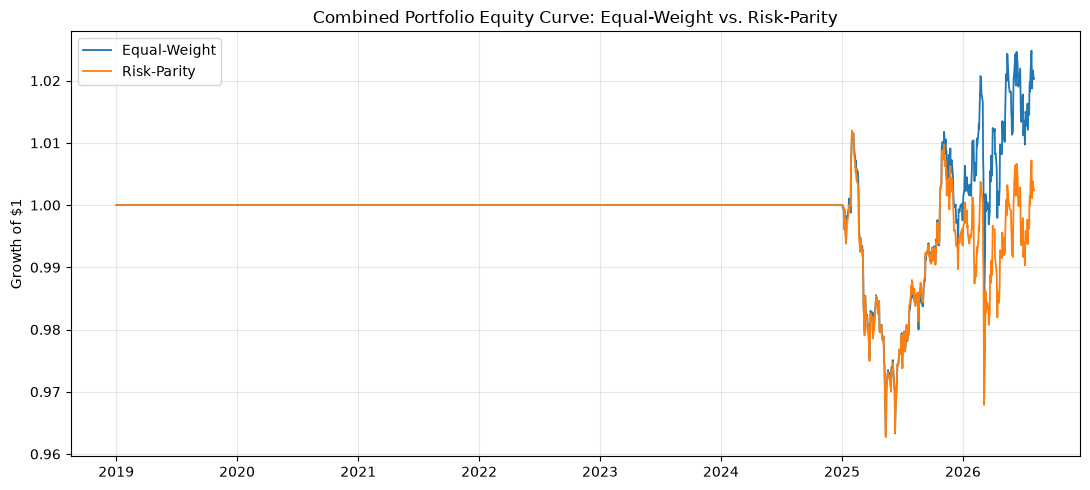

In [87]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(equal_backtest.index, equal_backtest["equity_curve"], label="Equal-Weight", linewidth=1.3)
ax.plot(risk_parity_backtest.index, risk_parity_backtest["equity_curve"], label="Risk-Parity", linewidth=1.3)
ax.set_title("Combined Portfolio Equity Curve: Equal-Weight vs. Risk-Parity")
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [88]:
equal_turnover = compute_turnover(combined_equal)
rp_turnover = compute_turnover(combined_risk_parity)

print(f"Equal-weight average daily turnover: {equal_turnover.mean():.4f}")
print(f"Risk-parity average daily turnover: {rp_turnover.mean():.4f}")

Equal-weight average daily turnover: 0.3830
Risk-parity average daily turnover: 0.4138


In [89]:
print(f"First active date in combined_equal: {combined_equal[(combined_equal != 0).any(axis=1)].index.min()}")
print(f"First active date in combined_risk_parity: {combined_risk_parity[(combined_risk_parity != 0).any(axis=1)].index.min()}")

First active date in combined_equal: 2025-01-02 00:00:00
First active date in combined_risk_parity: 2025-01-02 00:00:00


In [92]:
from modules.backtest.cost_aware_backtest import run_cost_aware_backtest, compare_naive_vs_cost_aware

In [93]:
equal_comparison, equal_cost_drag = compare_naive_vs_cost_aware(combined_equal, close, cost_per_unit_turnover=0.0005)

print("Equal-weight: naive vs. cost-aware")
print(equal_comparison.round(4))
print(f"\nTotal return given up to costs: {equal_cost_drag:.4f}")

Equal-weight: naive vs. cost-aware
                       Naive (No Costs)  Cost-Aware
Total Return                     0.0203     -0.0544
Annualized Return                0.0027     -0.0349
Annualized Volatility            0.0182      0.0399
Sharpe Ratio                     0.1463     -0.8743
Max Drawdown                    -0.0480     -0.0775

Total return given up to costs: 0.0747


In [94]:
rp_comparison, rp_cost_drag = compare_naive_vs_cost_aware(combined_risk_parity, close, cost_per_unit_turnover=0.0005)

print("Risk-parity: naive vs. cost-aware")
print(rp_comparison.round(4))
print(f"\nTotal return given up to costs: {rp_cost_drag:.4f}")

Risk-parity: naive vs. cost-aware
                       Naive (No Costs)  Cost-Aware
Total Return                     0.0024     -0.0767
Annualized Return                0.0003     -0.0494
Annualized Volatility            0.0180      0.0395
Sharpe Ratio                     0.0173     -1.2501
Max Drawdown                    -0.0487     -0.0969

Total return given up to costs: 0.0790


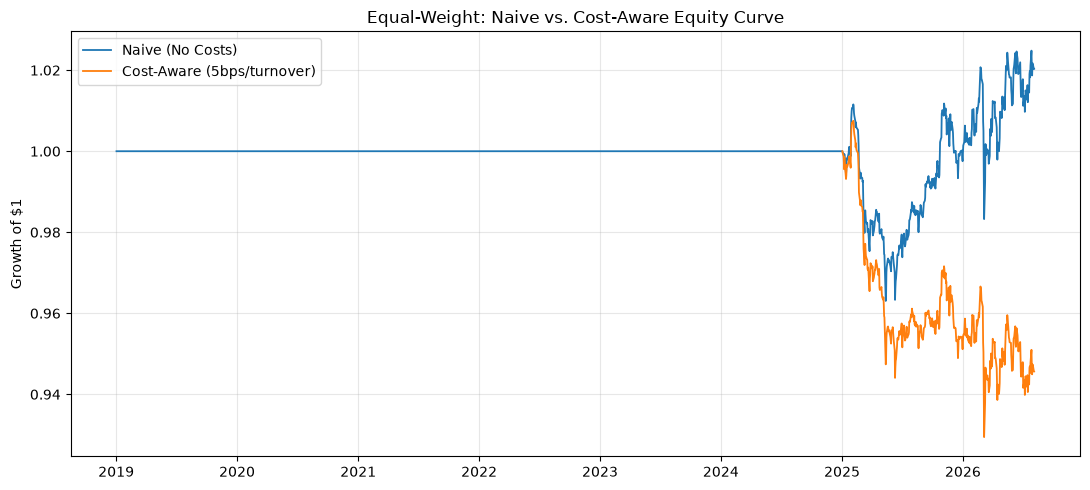

In [95]:
equal_cost_result = run_cost_aware_backtest(combined_equal, close, cost_per_unit_turnover=0.0005)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(equal_backtest.index, equal_backtest["equity_curve"], label="Naive (No Costs)", linewidth=1.3)
ax.plot(equal_cost_result.index, equal_cost_result["equity_curve"], label="Cost-Aware (5bps/turnover)", linewidth=1.3)
ax.set_title("Equal-Weight: Naive vs. Cost-Aware Equity Curve")
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<div style="font-family: 'Helvetica Neue', -apple-system, Arial, sans-serif;">

### Transaction Costs Turn a Flat Strategy Negative

The naive, frictionless version of the risk parity combined portfolio barely broke even over the backtest window: 0.24% total return, a Sharpe ratio of 0.017, essentially indistinguishable from doing nothing. Once a modest 5 basis point cost is applied per unit of daily turnover, the picture changes completely. Total return drops to -7.67%, Sharpe goes negative at -1.25, and max drawdown roughly doubles from -4.87% to -9.69%. The strategy gives up 7.9 percentage points of total return to trading costs alone.
___
*Drivers*

Turnover was running at 38 to 41% of the book every single day. That means, on an average day, the portfolio was trading nearly half its total gross exposure. Even a small cost per trade compounds fast at that pace, since it applies to a large fraction of the book on almost every day of the backtest, not occasionally.

The naive strategy also never had much of an edge to begin with. Momentum and Mean Reversion were both left deliberately simple and unrefined earlier in this project, on purpose, since the goal was building the pipeline rather than chasing predictive signals. A strategy with a thin edge and this much daily turnover has almost no chance of surviving realistic trading costs.
___
*A Useful Result*

This is the whole point of building the naive and cost aware backtests side by side. A pipeline that only ever reports the frictionless version would have hidden this completely, and the earlier diversification story (negative correlation between the two strategies, lower combined volatility) would have looked like a clean win on its own. Layering in costs shows that diversification benefit and profitability are two separate questions, and a strategy can pass the first test while failing the second.

*Next Steps*

A few directions worth considering from here: reducing rebalancing frequency, so the portfolio isn't recomputing and trading fresh targets every single day; adding a no trade band, so small, noisy changes in a signal's score don't trigger a full re-trade; or accepting that these particular naive signals were never meant to survive real trading costs, and treating this result as the expected, honest outcome of a deliberately simple starting point.
___

</div>

In [96]:
from modules.monitoring.portfolio_dashboard import build_monitoring_summary, plot_monitoring_dashboard

In [98]:
cost_aware_for_monitoring = pd.DataFrame({
    "daily_return": equal_cost_result["net_return"],
    "equity_curve": equal_cost_result["equity_curve"],
})

monitoring_summary = build_monitoring_summary(
    backtest_result=cost_aware_for_monitoring,
    weights=combined_equal,
    betas=betas,
    universe=universe,
)

monitoring_summary.tail()

,equity_curve,daily_return,drawdown,rolling_vol,turnover,beta_exposure,max_abs_sector_exposure
Date,,,,,,,
2026-07-29,0.944932,-0.002505,-0.062120,0.048249,0.321727,-0.000003,0.032955
2026-07-30,0.947376,0.002586,-0.059694,0.049220,0.445510,0.095145,0.034086
2026-07-31,0.947284,-0.000097,-0.059785,0.042514,0.362043,0.043001,0.032349
2026-08-03,0.945790,-0.001577,-0.061268,0.042422,0.404300,-0.052962,0.029772
2026-08-04,0.945627,-0.000173,-0.061430,0.039575,0.472733,0.000001,0.032412


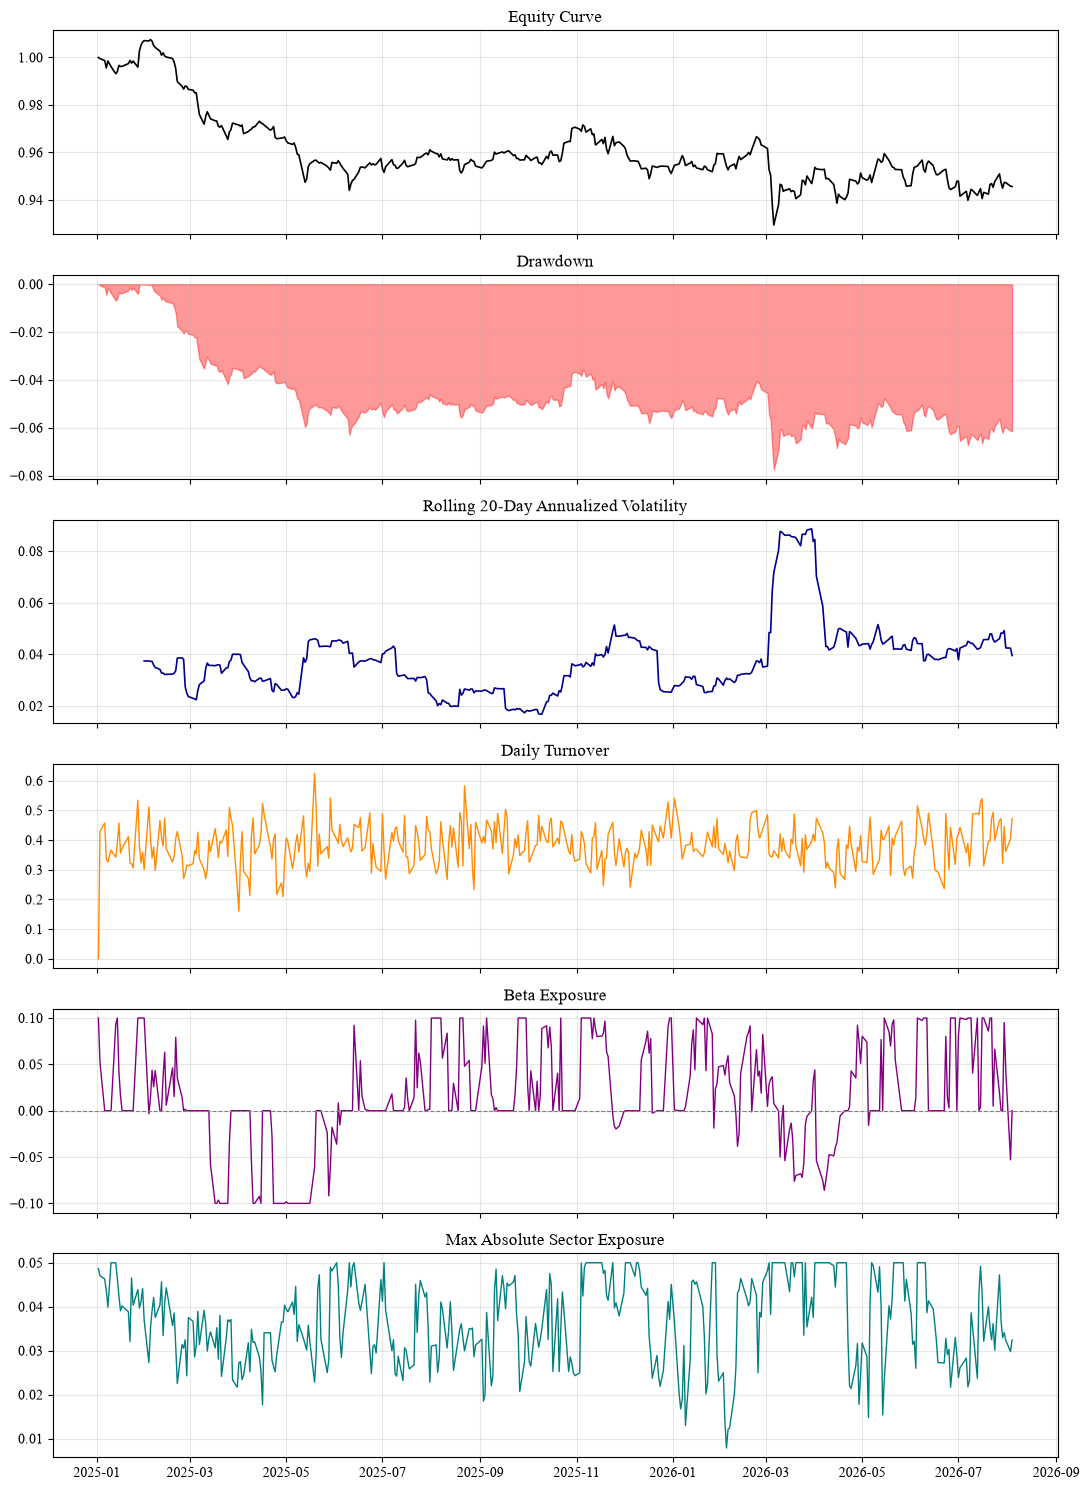

In [100]:
plot_monitoring_dashboard(monitoring_summary)